# Part 3 - Putting things into practice with the dataset of Computational Social Science abstracts
## Prelude to Exercise 1: Some theory on the Zipf’s law.

In [3]:
import pandas as pd

df = pd.read_csv("abstracts.csv")
type(df.iloc[0]["abstract_index"])

str

In [7]:
df["abstract_index"].isna().sum()

3008

In [9]:
import pandas as pd
import ast

def parse_abstract(x):
    if pd.isna(x):
        return {}
    return ast.literal_eval(x)

df["abstract_index"] = df["abstract_index"].apply(parse_abstract)

In [10]:
type(df.iloc[0]["abstract_index"])

dict

In [13]:
df.loc[0, "abstract_index"]

{'Preface.': [0],
 'Introduction.': [1],
 'Data': [2],
 'Sets.': [3],
 'Tests': [4],
 'of': [5, 8, 14, 25, 31, 67, 78, 82],
 'Statistical': [6],
 'Significance': [7],
 'Combined': [9],
 'Results.': [10],
 'Vote-Counting': [11],
 'Methods.': [12, 22, 42],
 'Estimation': [13, 24, 81],
 'a': [15, 29],
 'Single': [16],
 'Effect': [17, 26, 36, 39, 46, 49, 58, 63, 79, 83],
 'Size:': [18],
 'Parametric': [19, 23, 34, 44],
 'and': [20, 96],
 'Nonparametric': [21],
 'Size': [27, 84],
 'from': [28],
 'Series': [30],
 'Experiments.': [32],
 'Fitting': [33, 43],
 'Fixed': [35, 45],
 'Models': [37, 47, 56, 61],
 'to': [38, 48],
 'Sizes:': [40, 50],
 'Categorical': [41],
 'General': [51],
 'Linear': [52],
 'Models.': [53, 75],
 'Random': [54],
 'Effects': [55],
 'for': [57, 62, 72],
 'Sizes.': [59, 64],
 'Multivariate': [60],
 'Combining': [65],
 'Estimates': [66, 77],
 'Correlation': [68],
 'Coefficients.': [69],
 'Diagnostic': [70],
 'Procedures': [71],
 'Research': [73],
 'Synthesis': [74],
 'Clu

### Function converting indexes to text

In [14]:
import pandas as pd
import ast

# Load data
df = pd.read_csv("abstracts.csv")

# Parse abstract_index safely
def parse_abstract(x):
    if pd.isna(x):
        return {}
    return ast.literal_eval(x)

df["abstract_index"] = df["abstract_index"].apply(parse_abstract)

# Convert inverted index to plain text
def inverted_to_text(inv):
    if not inv:
        return ""
    
    max_pos = max(pos for positions in inv.values() for pos in positions)
    tokens = [""] * (max_pos + 1)
    
    for word, positions in inv.items():
        for pos in positions:
            tokens[pos] = word
    
    return " ".join(tokens)

# Apply to each row
df["text"] = df["abstract_index"].apply(inverted_to_text)

# Check result
print(df[["title", "text"]].head())

                                               title  \
0              Statistical Methods for Meta-Analysis   
1               Framing as a Theory of Media Effects   
2                   What Makes Online Content Viral?   
3  Framing, Agenda Setting, and Priming: The Evol...   
4  How to Do a Systematic Review: A Best Practice...   

                                                text  
0  Preface. Introduction. Data Sets. Tests of Sta...  
1  Research on framing is characterized by theore...  
2  Why are certain pieces of online content (e.g....  
3  This special issue of Journal of Communication...  
4  Systematic reviews are characterized by a meth...  


#### Add to dataframe the inverted text as a coulumn

In [15]:
df["text"] = df["abstract_index"].apply(inverted_to_text)

In [16]:
df.loc[0, "text"]

'Preface. Introduction. Data Sets. Tests of Statistical Significance of Combined Results. Vote-Counting Methods. Estimation of a Single Effect Size: Parametric and Nonparametric Methods. Parametric Estimation of Effect Size from a Series of Experiments. Fitting Parametric Fixed Effect Models to Effect Sizes: Categorical Methods. Fitting Parametric Fixed Effect Models to Effect Sizes: General Linear Models. Random Effects Models for Effect Sizes. Multivariate Models for Effect Sizes. Combining Estimates of Correlation Coefficients. Diagnostic Procedures for Research Synthesis Models. Clustering Estimates of Effect Magnitude. Estimation of Effect Size When Not All Study Outcomes Are Observed. Meta-Analysis in the Physical and Biological Sciences. Appendix. References. Index.'

### Tokenization

In [21]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/djphire/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/djphire/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import re
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

ps = PorterStemmer() 

def clean_and_tokenize(text):
    if not isinstance(text, str):
        return []
    
    # lowercase
    text = text.lower()
    
    # fjern URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # tokenization
    tokens = word_tokenize(text)
    
    # behold kun rene ord (fjern punctuation, tal osv.)
    tokens = [w for w in tokens if w.isalpha()]
    
    # optional: stemming
    tokens = [ps.stem(w) for w in tokens]
    
    return tokens

# anvend på dataframe
df["tokens"] = df["text"].apply(clean_and_tokenize)

# tjek resultat
print(df[["text", "tokens"]].head())

                                                text  \
0  Preface. Introduction. Data Sets. Tests of Sta...   
1  Research on framing is characterized by theore...   
2  Why are certain pieces of online content (e.g....   
3  This special issue of Journal of Communication...   
4  Systematic reviews are characterized by a meth...   

                                              tokens  
0  [prefac, introduct, data, set, test, of, stati...  
1  [research, on, frame, is, character, by, theor...  
2  [whi, are, certain, piec, of, onlin, content, ...  
3  [thi, special, issu, of, journal, of, commun, ...  
4  [systemat, review, are, character, by, a, meth...  


### Token list

In [24]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]

In [25]:
all_tokens[:20]

['prefac',
 'introduct',
 'data',
 'set',
 'test',
 'of',
 'statist',
 'signific',
 'of',
 'combin',
 'result',
 'method',
 'estim',
 'of',
 'a',
 'singl',
 'effect',
 'size',
 'parametr',
 'and']

### Top ten frequent words

In [26]:
from nltk import FreqDist

fdist = FreqDist(all_tokens)
top_10 = fdist.most_common(10)

print(top_10)

[('the', 74506), ('of', 56446), ('and', 46989), ('to', 35766), ('in', 31963), ('a', 29615), ('that', 19283), ('we', 18218), ('for', 14901), ('is', 13447)]


### Frequency rank plot

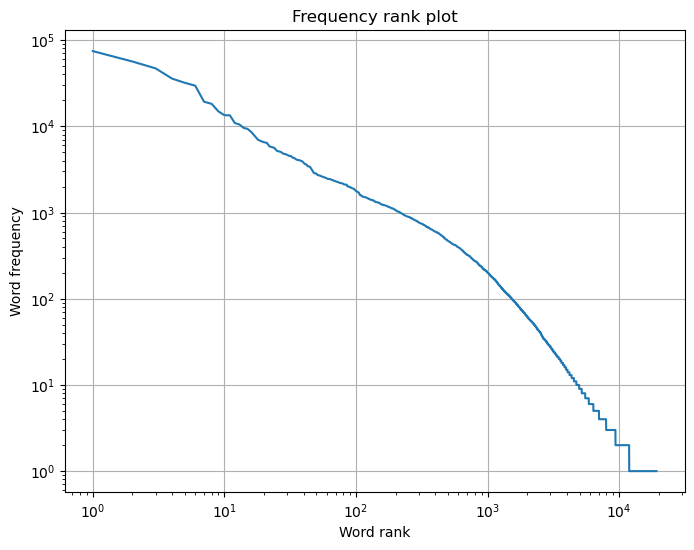

In [27]:
import matplotlib.pyplot as plt
from nltk import FreqDist

def plot_frequency_rank(tokens):
    # beregn frekvenser
    fdist = FreqDist(tokens)
    
    # sorter frekvenser fra størst til mindst
    freqs = sorted(fdist.values(), reverse=True)
    
    # ranks: 1, 2, 3, ...
    ranks = range(1, len(freqs) + 1)
    
    # plot
    plt.figure(figsize=(8, 6))
    plt.plot(ranks, freqs)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Word rank")
    plt.ylabel("Word frequency")
    plt.title("Frequency rank plot")
    plt.grid(True)
    plt.show()

# brug funktionen
plot_frequency_rank(all_tokens)

### Comparison with random words

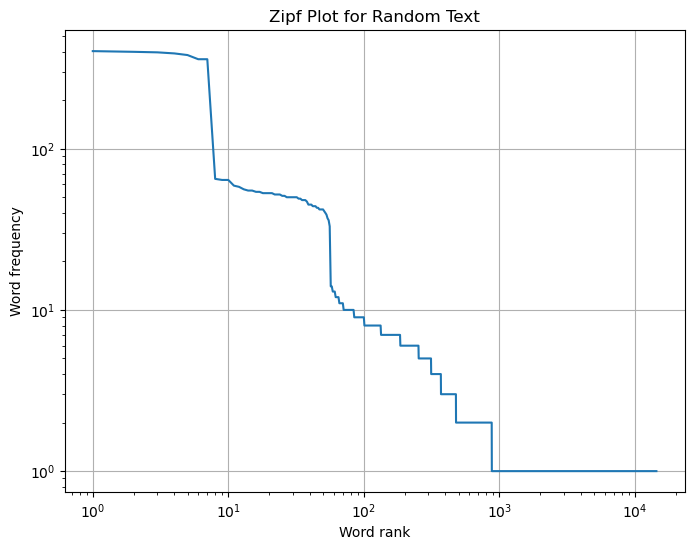

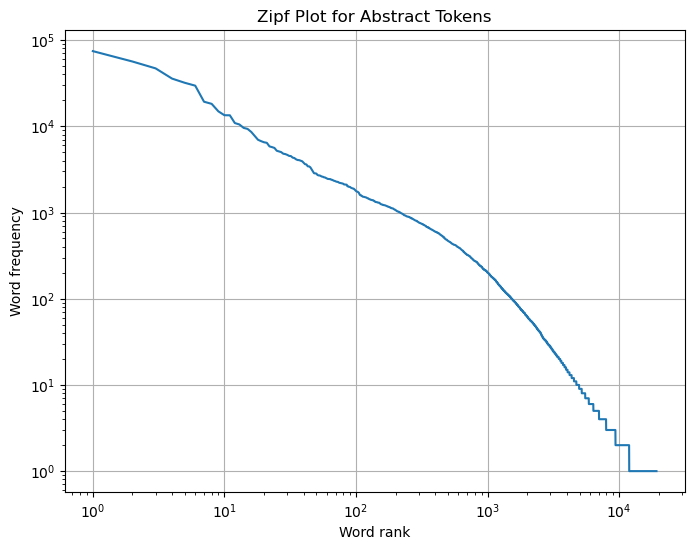

In [28]:
import random
import re
import matplotlib.pyplot as plt
from nltk import FreqDist

# 1. Lav en lang tilfældig tekst
random_text = "".join(random.choice("abcdefg ") for _ in range(200000))

# 2. Tokenize den
# Split på mellemrum og fjern tomme tokens
random_tokens = [tok for tok in random_text.split() if tok]

# 3. Funktion til Zipf-plot
def plot_zipf(tokens, title):
    fdist = FreqDist(tokens)
    freqs = sorted(fdist.values(), reverse=True)
    ranks = range(1, len(freqs) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(ranks, freqs)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Word rank")
    plt.ylabel("Word frequency")
    plt.title(title)
    plt.grid(True)
    plt.show()

# 4. Plot random tekst
plot_zipf(random_tokens, "Zipf Plot for Random Text")

# 5. Sammenlign med dit rigtige datasæt
plot_zipf(all_tokens, "Zipf Plot for Abstract Tokens")